# AudioMNIST Training Setup

## Prerequisites

Before training your CNN, you need to preprocess the raw audio data into HDF5 format.

## Preprocessing

Run
```bash
python preprocess.py \
    --source ./data \
    --destination ./preprocessed_data \
    --meta ./data/audioMNIST_meta.txt
```

### Parameters:
- `--source` - Path to raw audio data directory
- `--destination` - Where to save preprocessed HDF5 files
- `--meta` - Path to metadata JSON file

---

**Note:** This preprocessing step only needs to be run once. The files will be reused for all subsequent training runs.


In [1]:
# Testing cuda version
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name())

True
12.8
NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
# Training of a base CNN

from torch.utils.data import DataLoader
from torch.utils.data import Subset
from src_base.AudioMnist import AudioMNIST
from src_base.base_cnn import BaseCNN
import torch

# For digit classification with AudioNet
train_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='train'
)

val_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='validate'
)

test_dataset = AudioMNIST(
    root='./preprocessed_data',
    model_type='AudioNet',
    task='digit',
    split=0,
    mode='test'
)

# Extract only digit labels (index 0)
def collate_fn(batch):
    data, labels = zip(*batch)
    data = torch.stack(list(data)).unsqueeze(1)
    digit_labels = torch.tensor([l.flatten()[0].item() for l in labels])
    return data, digit_labels

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,collate_fn=collate_fn)

# small set for testing code
train_subset = Subset(train_dataset, range(len(train_dataset) // 5))
val_subset = Subset(val_dataset, range(len(val_dataset) // 5))

__s_train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, collate_fn=collate_fn)
__s_val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Initialize model
model = BaseCNN(nb_class=10)

# Train
nb_epochs = 10
tr_loss,val_accur,net = model.train_mod(nb_epoch=nb_epochs, trainLoader=train_loader, valLoader=val_loader)

device: cuda:0
Starting training over 10
Epoch 1/10,
  Train loss: 0.829647501927286,
  Validation Accuracy: 74%
Epoch 2/10,
  Train loss: 0.4704171930229685,
  Validation Accuracy: 82%
Epoch 3/10,
  Train loss: 0.34436358303678605,
  Validation Accuracy: 83%
Epoch 4/10,
  Train loss: 0.28660294521421353,
  Validation Accuracy: 86%
Epoch 5/10,
  Train loss: 0.254792761024531,
  Validation Accuracy: 86%
Epoch 6/10,
  Train loss: 0.2338980622424167,
  Validation Accuracy: 88%
Epoch 7/10,
  Train loss: 0.2111592637457708,
  Validation Accuracy: 90%
Epoch 8/10,
  Train loss: 0.18216731456698945,
  Validation Accuracy: 90%
Epoch 9/10,
  Train loss: 0.17768065599959548,
  Validation Accuracy: 89%
Epoch 10/10,
  Train loss: 0.1558418259302528,
  Validation Accuracy: 90%


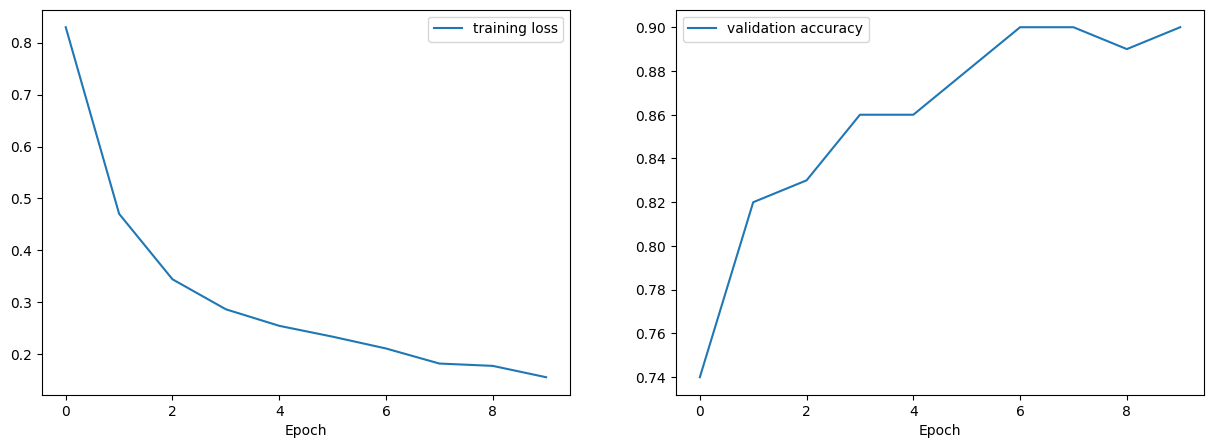

In [3]:
# Display of result

import numpy as np
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(np.arange(nb_epochs), tr_loss, label="training loss")
axs[1].plot(np.arange(nb_epochs), np.array(val_accur) / 100, label="validation accuracy")

for ax in axs:
    ax.set_xlabel("Epoch")
    ax.legend()
plt.show()

Saving model

In [4]:
PATH = 'models/base_net.pth'
torch.save(net.state_dict(), PATH)

Small benchmarking

In [5]:
cnn_net = BaseCNN()
cnn_net.load_state_dict(torch.load(PATH, weights_only=True))
net=cnn_net.to_device()
dataiter = iter(test_loader)
sounds,labels = next(dataiter)
sounds, labels = sounds.to(cnn_net.device), labels.to(cnn_net.device)
outputs = net(sounds)
_, predicted = torch.max(outputs, 1)

digits = ('0','1','2','3','4','5','6','7','8','9')
print('Predicted: ', ''.join(f'{digits[predicted[j]]:5s}'
                              for j in range(10)))
print('Real values',''.join(f'{digits[labels[j]]:5s}'
                              for j in range(10)))

device: cuda:0
Predicted:  7    3    2    0    4    3    7    0    4    0    
Real values 0    0    0    0    0    0    0    0    0    0    


Full bencharmking

In [6]:
net.eval()

correct = 0
total = 0

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Global prediction
with torch.no_grad():
    for (sounds, labels) in test_loader:
        sounds, labels = sounds.to(device), labels.to(device)
        outputs = net(sounds)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {len(test_loader)} test sound: {100 * correct // total} %')

# Full benchmark for each digit
correct_pred = {digit: 0 for digit in digits}
total_pred = {digit: 0 for digit in digits}

# Counting by digits again
with torch.no_grad():
    for (sound, labels) in test_loader:
        sound, labels = sound.to(device), labels.to(device)
        outputs = net(sound)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[digits[label]] += 1
            total_pred[digits[label]] += 1


# print accuracy for each digit
for digit, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[digit]
    print(f'Accuracy for class: {digit:5s} is {accuracy:.1f} %')

device: cuda:0
Accuracy of the network on the 188 test sound: 91 %
Accuracy for class: 0     is 95.3 %
Accuracy for class: 1     is 99.3 %
Accuracy for class: 2     is 83.8 %
Accuracy for class: 3     is 90.2 %
Accuracy for class: 4     is 97.3 %
Accuracy for class: 5     is 95.0 %
Accuracy for class: 6     is 72.8 %
Accuracy for class: 7     is 92.2 %
Accuracy for class: 8     is 99.7 %
Accuracy for class: 9     is 87.0 %
